# Buổi 4 · Ngân hàng tình huống Perceptron

Notebook gồm **10 chủ đề mở** và một mẫu thực hành từng bước. Không có dữ liệu hoặc lời giải dựng sẵn; các code cell chỉ chứa comment định hướng để mỗi nhóm tự thu thập dữ liệu, xử lý, huấn luyện, triển khai thử và kiểm thử.

## Khung suy nghĩ chung

Trước khi viết code, hãy trả lời bằng lời:

1. Đối tượng cần phân loại là gì?
2. Hai nhãn `0` và `1` có ý nghĩa gì?
3. Feature nào có thể biết **trước thời điểm ra quyết định**?
4. Feature nào có thể vô tình chứa đáp án và gây data leakage?
5. Sai lớp nào gây hậu quả lớn hơn?
6. Vì sao một ranh giới tuyến tính có thể phù hợp hoặc chưa phù hợp?

## 01 · Cảnh báo máy quá tải

Dùng nhiệt độ động cơ, độ rung, dòng điện và thời gian chạy để dự đoán máy có cần dừng kiểm tra hay không. Hãy tập trung phân tích lỗi **bỏ sót một máy nguy hiểm**.

In [22]:
# Nếu chọn tình huống 01, hãy tự thiết kế dữ liệu và viết code tại đây.

## 02 · Quyết định tưới cây

Dùng độ ẩm đất, nhiệt độ, thời gian từ lần tưới gần nhất và dự báo mưa để quyết định bật máy bơm. Hãy kiểm tra dấu của từng trọng số có khớp với trực giác hay không.

In [23]:
# Nếu chọn tình huống 02, hãy tự thiết kế dữ liệu và viết code tại đây.

## 03 · Cảnh báo giao hàng trễ

Dùng khoảng cách, số đơn tài xế đang giữ, trời mưa, giờ cao điểm và thời gian chuẩn bị để dự đoán nguy cơ giao trễ. Hãy tự quyết định cách mã hoá các feature có/không.

In [24]:
# Nếu chọn tình huống 03, hãy tự thiết kế dữ liệu và viết code tại đây.

## 04 · Kiểm tra sản phẩm cuối dây chuyền

Dùng độ lệch khối lượng, độ lệch kích thước, số vết xước và điểm màu để dự đoán sản phẩm có cần kiểm tra lại hay không. Hãy suy nghĩ vì sao **độ lệch tuyệt đối** hữu ích hơn kích thước thô.

In [25]:
# Nếu chọn tình huống 04, hãy tự thiết kế dữ liệu và viết code tại đây.

## 05 · Ưu tiên phiếu hỗ trợ khách hàng

Dùng số từ khẩn cấp, trạng thái gián đoạn dịch vụ, thời gian chờ và mức khách hàng để dự đoán phiếu có cần ưu tiên. Hãy nêu feature nào có nguy cơ gây thiên lệch và quyết định nào vẫn cần con người xem lại.

In [26]:
# Nếu chọn tình huống 05, hãy tự thiết kế dữ liệu và viết code tại đây.

## 06 · Đề xuất miễn phí vận chuyển

Dùng giá trị đơn hàng, khoảng cách, hạng thành viên và khối lượng kiện hàng để đề xuất miễn phí vận chuyển. Hãy tạo thêm các mẫu nằm gần ranh giới thay vì chỉ tạo những trường hợp quá dễ.

In [27]:
# Nếu chọn tình huống 06, hãy tự thiết kế dữ liệu và viết code tại đây.

## 07 · Cảnh báo thông gió phòng học

Dùng nồng độ CO2, nhiệt độ, độ ẩm, số người và thời gian đóng cửa để dự đoán khi nào cần thông gió. Hãy tự đề xuất cách gắn nhãn mà không biến một ngưỡng CO2 duy nhất thành đáp án có sẵn.

In [28]:
# Nếu chọn tình huống 07, hãy tự thiết kế dữ liệu và viết code tại đây.

## 08 · Lọc email rác đơn giản

Chuyển email thành các feature số như số liên kết, số từ viết hoa, số dấu chấm than và độ dài tiêu đề. Hãy ẩn thông tin cá nhân, ghi lại quy tắc gắn nhãn và so sánh hậu quả của chặn nhầm với bỏ sót thư rác.

In [29]:
# Nếu chọn tình huống 08, hãy tự thiết kế dữ liệu và viết code tại đây.

## 09 · Cảnh báo nhập thêm hàng

Dùng tồn kho, lượng bán trung bình, thời gian chờ hàng và số đơn đang chờ để dự đoán có cần nhập thêm hay không. Hãy ghi rõ mốc thời gian quan sát để dữ liệu tương lai không lọt vào feature.

In [30]:
# Nếu chọn tình huống 09, hãy tự thiết kế dữ liệu và viết code tại đây.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Đặt seed để kết quả có thể lặp lại
np.random.seed(42)

print("Đã chọn Tình huống 09 - Cảnh báo nhập thêm hàng")
print("Mục tiêu: dự đoán sản phẩm có cần nhập thêm hàng trong kỳ kế tiếp hay không.")

Đã chọn Tình huống 09 - Cảnh báo nhập thêm hàng
Mục tiêu: dự đoán sản phẩm có cần nhập thêm hàng trong kỳ kế tiếp hay không.


## 10 · Gợi ý hỗ trợ học tập

Dùng dữ liệu học tập phù hợp như tỷ lệ tham dự, mức hoàn thành bài luyện tập, số bài nộp trễ và điểm quiz gần nhất để gợi ý hỗ trợ thêm. Đây chỉ là tín hiệu để giảng viên xem xét, không phải kết luận về năng lực sinh viên.

In [31]:
# Nếu chọn tình huống 10, hãy tự thiết kế dữ liệu và viết code tại đây.

## Phiếu thiết kế trước khi lập trình

| Mục | Câu trả lời của nhóm |
| --- | --- |
| Tình huống đã chọn | Tình huống 09 – Cảnh báo nhập thêm hàng |
| Đối tượng được phân loại |Một sản phẩm tại một ngày quan sát cụ thể  |
| Ý nghĩa nhãn 0 / 1 | 0: Chưa cần nhập thêm hàng. 1: Cần nhập thêm hàng trong kỳ kế tiếp  |
| Danh sách feature và đơn vị | ton_kho: số lượng tồn kho, đơn vị sản phẩm. ban_tb_ngay: lượng bán trung bình mỗi ngày, đơn vị sản phẩm/ngày. cho_hang_ngay: số ngày chờ hàng, đơn vị ngày. don_dang_cho: số đơn hàng đang chờ, đơn vị đơn hàng|
| Cách tạo / thu thập dữ liệu | Tạo dữ liệu mô phỏng dựa trên tình trạng tồn kho, lượng bán trung bình, thời gian chờ hàng và số đơn đang chờ. Dữ liệu được ghi tại thời điểm quyết định nhập hàng. Nhãn được xác định dựa trên nhu cầu trong kỳ kế tiếp. |
| Lỗi cần ưu tiên giảm | Ưu tiên giảm False Negative – dự đoán chưa cần nhập hàng nhưng thực tế lại cần nhập, vì có thể dẫn đến hết hàng và mất doanh thu. |
| Dự đoán giới hạn của Perceptron | Perceptron chỉ phân loại tốt khi dữ liệu gần phân tách tuyến tính. Mô hình có thể dự đoán sai các trường hợp nằm gần ranh giới hoặc các tình huống phức tạp. |
| Người chịu trách nhiệm xem lại dự đoán | Nhân viên quản lý kho hoặc người phụ trách nhập hàng kiểm tra lại các dự đoán trước khi quyết định nhập hàng. |

# Mẫu thực hành step by step

Đi lần lượt từ Bước 0 đến Bước 10. Mỗi bước có **việc cần làm**, **kết quả cần ghi lại** và một code cell chỉ chứa comment. Không xoá phần giải thích; hãy viết code của nhóm ngay dưới comment tương ứng.

## Bước 0 · Đóng khung bài toán

- Chọn đúng **một** trong 10 tình huống.
- Viết câu hỏi mà mô hình phải trả lời tại một thời điểm cụ thể.
- Định nghĩa rõ `y = 0`, `y = 1` và hành động sau mỗi dự đoán.
- Chọn lỗi cần ưu tiên giảm: false positive hay false negative.

**Kết quả cần ghi:** một đoạn 3–5 câu, không bắt đầu bằng code.

In [32]:
# TODO Bước 0: ghi tên tình huống, ý nghĩa nhãn và loại lỗi cần ưu tiên.
# Tình huống 09: Cảnh báo nhập thêm hàng.
# Đơn vị quan sát: một sản phẩm tại một ngày quyết định nhập hàng.
# Nhãn y = 0: chưa cần nhập thêm; y = 1: cần nhập thêm trong kỳ kế tiếp.
# Ưu tiên giảm False Negative vì dự đoán thiếu nhu cầu có thể làm cửa hàng hết hàng.

## Bước 1 · Lập kế hoạch thu thập và gắn nhãn

1. Chọn **đơn vị quan sát**: mỗi dòng dữ liệu đại diện cho điều gì?
2. Lập data dictionary gồm tên cột, ý nghĩa, đơn vị, kiểu dữ liệu và phạm vi hợp lý.
3. Chọn nguồn: đo thực tế, ghi nhận thủ công, dữ liệu công khai hoặc mô phỏng. Nếu mô phỏng, phải công bố quy tắc tạo.
4. Mô tả ai gắn nhãn, gắn ở thời điểm nào và xử lý bất đồng ra sao.
5. Không thu thập dữ liệu cá nhân không cần thiết; ẩn danh trước khi đưa vào notebook.
6. Cố gắng có đủ cả hai lớp và các trường hợp gần ranh giới, không chỉ các mẫu dễ.

**Kết quả cần ghi:** data dictionary, nguồn dữ liệu, số mẫu dự kiến và quy tắc gắn nhãn.

In [ ]:
# TODO Bước 1: tạo/thu thập dữ liệu và lưu thành CSV; không đưa thông tin cá nhân vào file.
# TODO: ghi nguồn, thời điểm thu thập và quy tắc gắn nhãn trong báo cáo.

import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 600

data = pd.DataFrame({
    "ngay": pd.date_range(
        start="2025-01-01",
        periods=n_samples,
        freq="D"
    ),
    "san_pham": np.random.choice(
        ["SP01", "SP02", "SP03", "SP04", "SP05"],
        size=n_samples
    ),
    "ton_kho": np.random.randint(0, 101, size=n_samples),
    "ban_tb_ngay": np.round(
        np.random.uniform(1, 30, size=n_samples),
        2
    ),
    "cho_hang_ngay": np.random.randint(1, 15, size=n_samples),
    "don_dang_cho": np.random.randint(0, 31, size=n_samples)
})

# Nhu cầu dự kiến trong thời gian chờ hàng.
# Đây là biến trung gian để tạo nhãn trong dữ liệu mô phỏng.
data["nhu_cau_trong_thoi_gian_cho"] = (
    data["ban_tb_ngay"] * data["cho_hang_ngay"]
)

# Nếu tồn kho và số đơn đang chờ không đủ đáp ứng nhu cầu,
# gán nhãn cần nhập thêm hàng.
data["y"] = (
    data["ton_kho"] + data["don_dang_cho"]
    < data["nhu_cau_trong_thoi_gian_cho"]
).astype(int)

# Lưu dữ liệu thành file CSV
data.to_csv(
    "du_lieu_canh_bao_nhap_hang.csv",
    index=False
)

print("Đã tạo dữ liệu mô phỏng.")
print("Số dòng dữ liệu:", len(data))
print("Đã lưu file: du_lieu_canh_bao_nhap_hang.csv")

display(data.head())

Đã tạo dữ liệu mô phỏng.
Số dòng dữ liệu: 600
Đã lưu file: du_lieu_canh_bao_nhap_hang.csv


,ngay,san_pham,ton_kho,ban_tb_ngay,cho_hang_ngay,don_dang_cho,nhu_cau_trong_thoi_gian_cho,y
0,2025-01-01,SP04,74,29.91,7,1,209.37,1
1,2025-01-02,SP05,100,15.56,7,7,108.92,1
2,2025-01-03,SP03,35,18.27,10,26,182.70,1
3,2025-01-04,SP05,98,2.95,11,21,32.45,0
4,2025-01-05,SP05,18,22.75,10,7,227.50,1


## Bước 2 · Đọc và kiểm tra dữ liệu thô

- Đọc CSV và hiển thị một số dòng đầu/cuối.
- Kiểm tra kích thước bảng, kiểu dữ liệu, giá trị thiếu, dòng trùng và giá trị ngoài phạm vi.
- Đếm số mẫu của từng nhãn; không kết luận chỉ từ accuracy nếu lớp bị lệch.
- Giữ một bản dữ liệu thô bất biến để có thể đối chiếu.

**Kết quả cần ghi:** bảng tóm tắt vấn đề dữ liệu và quyết định xử lý cho từng vấn đề.

In [ ]:
# TODO Bước 2: import thư viện, đọc CSV và kiểm tra cấu trúc dữ liệu.
# TODO: thống kê missing, duplicate, phạm vi feature và phân bố nhãn.


import pandas as pd
import numpy as np

df = pd.read_csv(
    "du_lieu_canh_bao_nhap_hang.csv"
)

# Giữ một bản sao dữ liệu thô để đối chiếu
df_raw = df.copy()

print("Kích thước dữ liệu:", df.shape)
print("\nNăm dòng đầu:")
display(df.head())

print("\nNăm dòng cuối:")
display(df.tail())

print("\nKiểu dữ liệu:")
print(df.dtypes)

print("\nSố lượng giá trị thiếu:")
print(df.isnull().sum())

print("\nSố dòng trùng lặp:", df.duplicated().sum())

print("\nThống kê mô tả:")
display(df.describe())

print("\nPhân bố nhãn:")
print(df["y"].value_counts())

Kích thước dữ liệu: (600, 8)

Năm dòng đầu:


,ngay,san_pham,ton_kho,ban_tb_ngay,cho_hang_ngay,don_dang_cho,nhu_cau_trong_thoi_gian_cho,y
0,2025-01-01,SP04,74,29.91,7,1,209.37,1
1,2025-01-02,SP05,100,15.56,7,7,108.92,1
2,2025-01-03,SP03,35,18.27,10,26,182.70,1
3,2025-01-04,SP05,98,2.95,11,21,32.45,0
4,2025-01-05,SP05,18,22.75,10,7,227.50,1



Năm dòng cuối:


,ngay,san_pham,ton_kho,ban_tb_ngay,cho_hang_ngay,don_dang_cho,nhu_cau_trong_thoi_gian_cho,y
595,2026-08-19,SP05,48,20.51,8,23,164.08,1
596,2026-08-20,SP05,19,13.87,5,27,69.35,1
597,2026-08-21,SP05,85,26.18,12,27,314.16,1
598,2026-08-22,SP05,91,6.14,11,8,67.54,0
599,2026-08-23,SP05,62,21.09,7,3,147.63,1



Kiểu dữ liệu:
ngay                               str
san_pham                           str
ton_kho                          int64
ban_tb_ngay                    float64
cho_hang_ngay                    int64
don_dang_cho                     int64
nhu_cau_trong_thoi_gian_cho    float64
y                                int64
dtype: object

Số lượng giá trị thiếu:
ngay                           0
san_pham                       0
ton_kho                        0
ban_tb_ngay                    0
cho_hang_ngay                  0
don_dang_cho                   0
nhu_cau_trong_thoi_gian_cho    0
y                              0
dtype: int64

Số dòng trùng lặp: 0

Thống kê mô tả:


,ton_kho,ban_tb_ngay,cho_hang_ngay,don_dang_cho,nhu_cau_trong_thoi_gian_cho,y
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,49.140000,15.468167,7.386667,15.443333,116.326400,0.621667
std,29.703101,8.620707,4.075722,8.670953,99.523015,0.485376
min,0.000000,1.140000,1.000000,0.000000,1.520000,0.000000
25%,24.000000,7.670000,4.000000,8.000000,36.595000,0.000000
50%,50.000000,15.515000,7.000000,16.000000,88.640000,1.000000
75%,74.000000,22.990000,11.000000,23.000000,176.742500,1.000000
max,100.000000,29.940000,14.000000,30.000000,418.880000,1.000000



Phân bố nhãn:
y
1    373
0    227
Name: count, dtype: int64


## Bước 3 · Chọn feature và kiểm tra data leakage

Với từng cột, hỏi: **giá trị này có thật sự tồn tại trước lúc mô hình ra quyết định không?** Loại cột định danh, cột chứa trực tiếp đáp án và thông tin chỉ xuất hiện sau kết quả. Sau đó xác định thứ tự cố định cho các feature trong `X` và nhãn trong `y`.

**Kết quả cần ghi:** danh sách feature được giữ/loại cùng lý do.

In [ ]:
# TODO Bước 3: tạo X, y; cố định feature_names và giải thích mọi cột bị loại.
# TODO: kiểm tra X và y có cùng số dòng, y chỉ chứa 0/1.

feature_names = [
    "ton_kho",
    "ban_tb_ngay",
    "cho_hang_ngay",
    "don_dang_cho"
]

X = df[feature_names].copy()
y = df["y"].copy()

print("Các feature được chọn:")
print(feature_names)

print("\nKích thước X:", X.shape)
print("Kích thước y:", y.shape)

print("\nKiểm tra giá trị thiếu trong X:")
print(X.isnull().sum())

print("\nCác giá trị nhãn:", sorted(y.unique()))

display(X.head())
display(y.head())

Các feature được chọn:
['ton_kho', 'ban_tb_ngay', 'cho_hang_ngay', 'don_dang_cho']

Kích thước X: (600, 4)
Kích thước y: (600,)

Kiểm tra giá trị thiếu trong X:
ton_kho          0
ban_tb_ngay      0
cho_hang_ngay    0
don_dang_cho     0
dtype: int64

Các giá trị nhãn: [np.int64(0), np.int64(1)]


,ton_kho,ban_tb_ngay,cho_hang_ngay,don_dang_cho
0,74,29.91,7,1
1,100,15.56,7,7
2,35,18.27,10,26
3,98,2.95,11,21
4,18,22.75,10,7


0    1
1    1
2    1
3    0
4    1
Name: y, dtype: int64

## Bước 4 · Chia train/test trước khi học tham số xử lý

- Chọn cách chia ngẫu nhiên có giữ tỷ lệ lớp hoặc chia theo thời gian, tuỳ tình huống.
- Đặt `random_state` để tái lập kết quả nếu chia ngẫu nhiên.
- Tuyệt đối không dùng test để chọn feature, tính trung bình/độ lệch chuẩn hay điều chỉnh mô hình.

**Kết quả cần ghi:** kích thước và phân bố nhãn của train/test; giải thích cách chia.

In [ ]:
# TODO Bước 4: chia X_train, X_test, y_train, y_test theo chiến lược đã chọn.
# TODO: in kích thước và số lượng từng lớp trong hai tập.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test:", X_test.shape)

print("\nPhân bố nhãn trong tập train:")
print(y_train.value_counts(normalize=True))

print("\nPhân bố nhãn trong tập test:")
print(y_test.value_counts(normalize=True))

Kích thước tập train: (480, 4)
Kích thước tập test: (120, 4)

Phân bố nhãn trong tập train:
y
1    0.620833
0    0.379167
Name: proportion, dtype: float64

Phân bố nhãn trong tập test:
y
1    0.625
0    0.375
Name: proportion, dtype: float64


## Bước 5 · Làm sạch và biến đổi dữ liệu

- Quyết định cách xử lý missing, duplicate và outlier; không âm thầm xoá dữ liệu.
- Mã hoá feature phân loại thành số nếu có.
- Chuẩn hoá feature có thang đo khác nhau. Chỉ `fit` bộ biến đổi trên train, sau đó dùng cùng tham số để `transform` test.
- Kiểm tra sau xử lý không còn `NaN`, vô cùng hoặc sai thứ tự cột.

**Kết quả cần ghi:** quy tắc xử lý và tham số cần tái sử dụng khi triển khai.

In [ ]:
# TODO Bước 5: fit bước xử lý trên train, rồi transform cả train và test.
# TODO: xác nhận dữ liệu sau xử lý là số hữu hạn và giữ nguyên thứ tự feature.

from sklearn.preprocessing import StandardScaler

# Kiểm tra dữ liệu thiếu
print("Giá trị thiếu trong X_train:")
print(X_train.isnull().sum())

print("\nGiá trị thiếu trong X_test:")
print(X_test.isnull().sum())

# Chuẩn hóa feature
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nKích thước X_train_scaled:", X_train_scaled.shape)
print("Kích thước X_test_scaled:", X_test_scaled.shape)

print("\nMột số dòng dữ liệu sau chuẩn hóa:")
display(pd.DataFrame(
    X_train_scaled,
    columns=feature_names
).head())

Giá trị thiếu trong X_train:
ton_kho          0
ban_tb_ngay      0
cho_hang_ngay    0
don_dang_cho     0
dtype: int64

Giá trị thiếu trong X_test:
ton_kho          0
ban_tb_ngay      0
cho_hang_ngay    0
don_dang_cho     0
dtype: int64

Kích thước X_train_scaled: (480, 4)
Kích thước X_test_scaled: (120, 4)

Một số dòng dữ liệu sau chuẩn hóa:


,ton_kho,ban_tb_ngay,cho_hang_ngay,don_dang_cho
0,1.495447,-0.906989,-0.094349,1.590838
1,1.360290,-1.549954,0.151780,1.015837
2,1.191345,-0.038463,0.397909,-0.824169
3,-1.579356,1.625339,1.628554,1.015837
4,-1.545567,0.742861,0.397909,0.210834


## Bước 6 · Huấn luyện Perceptron

- Chọn learning rate, số epoch và giá trị khởi tạo `w`, `b`.
- Với mỗi mẫu, tính `net = wᵀx + b`, đưa qua hàm step để có `ŷ`, rồi tính `e = y - ŷ`.
- Chỉ cập nhật khi dự đoán sai; lưu số lỗi theo epoch để quan sát hội tụ.
- Có thể dùng lớp tự cài đặt hoặc thư viện, nhưng phải giải thích được `w`, `b` và một lượt cập nhật.

**Kết quả cần ghi:** cấu hình, số epoch thực tế, trọng số/bias cuối và đồ thị số lỗi.

Learning rate: 0.1
Số epoch: 30
Trọng số cuối cùng: [-0.51773257  0.57550079  0.51317922 -0.05175016]
Bias cuối cùng: 0.30000000000000004


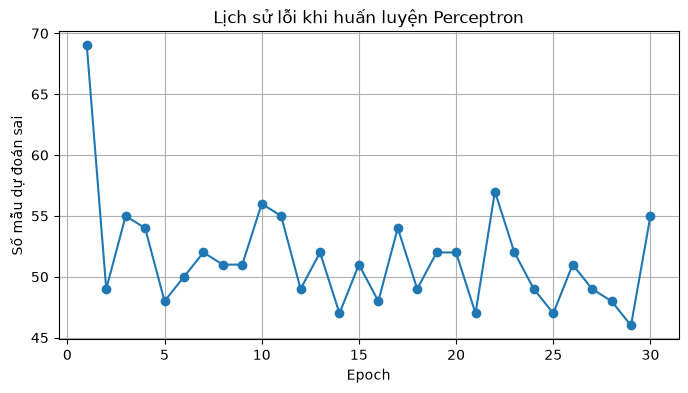

In [ ]:
# TODO Bước 6: huấn luyện Perceptron chỉ bằng tập train.
# TODO: lưu lịch sử số mẫu sai mỗi epoch và in w, b sau huấn luyện.

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=30):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.errors_per_epoch = []

    def step_function(self, value):
        if value >= 0:
            return 1
        return 0

    def predict_one(self, x):
        net = np.dot(x, self.weights) + self.bias
        return self.step_function(net)

    def fit(self, X, y):
        # Khởi tạo trọng số và bias
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        self.errors_per_epoch = []

        for epoch in range(self.epochs):
            errors = 0

            for xi, target in zip(X, y):
                prediction = self.predict_one(xi)

                # Sai số
                error = target - prediction

                # Chỉ cập nhật khi dự đoán sai
                if error != 0:
                    self.weights += (
                        self.learning_rate * error * xi
                    )
                    self.bias += (
                        self.learning_rate * error
                    )
                    errors += 1

            self.errors_per_epoch.append(errors)

        return self


# Khởi tạo và huấn luyện mô hình
model = Perceptron(
    learning_rate=0.1,
    epochs=30
)

model.fit(
    X_train_scaled,
    y_train.to_numpy()
)

print("Learning rate:", model.learning_rate)
print("Số epoch:", model.epochs)
print("Trọng số cuối cùng:", model.weights)
print("Bias cuối cùng:", model.bias)

# Vẽ số mẫu dự đoán sai theo từng epoch
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, model.epochs + 1),
    model.errors_per_epoch,
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Số mẫu dự đoán sai")
plt.title("Lịch sử lỗi khi huấn luyện Perceptron")
plt.grid(True)
plt.show()

## Bước 7 · Đánh giá trên dữ liệu chưa thấy

- Chỉ dự đoán test sau khi hoàn tất lựa chọn mô hình.
- Báo cáo confusion matrix; tính accuracy và ít nhất recall của lớp quan trọng.
- Chọn tối thiểu hai mẫu sai, tính lại `net` và giải thích chúng nằm ở đâu so với ranh giới.
- So sánh với baseline đơn giản như luôn đoán lớp phổ biến.

**Kết quả cần ghi:** metric, confusion matrix, phép tính tay một mẫu và phân tích lỗi.

Accuracy: 0.85

Classification report:
               precision    recall  f1-score   support

Chưa cần nhập       0.85      0.73      0.79        45
     Cần nhập       0.85      0.92      0.88        75

     accuracy                           0.85       120
    macro avg       0.85      0.83      0.84       120
 weighted avg       0.85      0.85      0.85       120


Confusion matrix:
[[33 12]
 [ 6 69]]


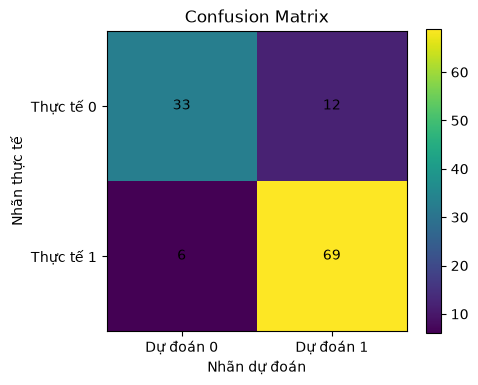

Baseline accuracy: 0.625

Trọng số của mô hình:
ton_kho: -0.517733
ban_tb_ngay: 0.575501
cho_hang_ngay: 0.513179
don_dang_cho: -0.051750

Giải thích hướng tác động:
- Trọng số âm: feature tăng làm net giảm, xu hướng dự đoán lớp 0.
- Trọng số dương: feature tăng làm net tăng, xu hướng dự đoán lớp 1.
- Cần xem dấu trọng số sau khi chạy để kết luận cụ thể.


In [ ]:
# TODO Bước 7: dự đoán test, tính metric và vẽ/hiển thị confusion matrix.
# TODO: tìm ít nhất hai mẫu sai và tính net của một mẫu bằng tay.


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Dự đoán trên tập test
y_pred = np.array([
    model.predict_one(x)
    for x in X_test_scaled
])

# Tính accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))

# In classification report
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Chưa cần nhập",
            "Cần nhập"
        ],
        zero_division=0
    )
)

# Tạo confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion matrix:")
print(cm)

# Hiển thị confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["Dự đoán 0", "Dự đoán 1"]
)
plt.yticks(
    [0, 1],
    ["Thực tế 0", "Thực tế 1"]
)

plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# So sánh với baseline: luôn dự đoán lớp phổ biến nhất
majority_class = y_train.mode()[0]

baseline_pred = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline accuracy:", round(baseline_accuracy, 4))

# In trọng số theo từng feature
print("\nTrọng số của mô hình:")
for feature, weight in zip(
    feature_names,
    model.weights
):
    print(f"{feature}: {weight:.6f}")

print("\nGiải thích hướng tác động:")
print("- Trọng số âm: feature tăng làm net giảm, xu hướng dự đoán lớp 0.")
print("- Trọng số dương: feature tăng làm net tăng, xu hướng dự đoán lớp 1.")
print("- Cần xem dấu trọng số sau khi chạy để kết luận cụ thể.")

## Bước 8 · Đóng gói để triển khai thử

Tạo một hàm dự đoán cho **một bản ghi mới**. Hàm phải kiểm tra đủ cột, đúng kiểu, đúng phạm vi; áp dụng chính xác bước xử lý đã học từ train; trả về `net`, nhãn dự đoán và thông báo dễ hiểu. Lưu cùng nhau: thứ tự feature, tham số xử lý, `w`, `b`, ánh xạ nhãn và phiên bản mô hình.

> Triển khai trong bài này chỉ cần chạy cục bộ trong notebook hoặc một file Python; chưa cần web server.

**Kết quả cần ghi:** giao diện input/output của hàm và nơi lưu artifact.

In [ ]:
# TODO Bước 8: viết predict_one(record) gồm validate -> transform -> net -> step.
# TODO: lưu và nạp lại feature_names, tham số xử lý, w, b và label_map.

label_map = {
    0: "Chưa cần nhập thêm hàng",
    1: "Cần nhập thêm hàng"
}

def predict_record(record):
    # Kiểm tra record có phải dạng dictionary hay không
    if not isinstance(record, dict):
        raise TypeError("Dữ liệu đầu vào phải là dictionary.")

    # Kiểm tra đủ feature bắt buộc
    missing_features = [
        feature for feature in feature_names
        if feature not in record
    ]

    if missing_features:
        raise ValueError(
            f"Thiếu feature bắt buộc: {missing_features}"
        )

    # Lấy feature theo đúng thứ tự lúc huấn luyện
    values = [record[feature] for feature in feature_names]

    # Kiểm tra kiểu dữ liệu và giá trị hợp lệ
    for feature, value in zip(feature_names, values):
        if not isinstance(value, (int, float, np.integer, np.floating)):
            raise TypeError(
                f"Feature {feature} phải là số."
            )

        if not np.isfinite(value):
            raise ValueError(
                f"Feature {feature} không được là NaN hoặc vô cùng."
            )

    # Chuẩn hóa bằng scaler đã fit trên tập train
    x_input = pd.DataFrame(
        [values],
        columns=feature_names
    )

    x_scaled = scaler.transform(x_input)[0]

    # Tính net và nhãn dự đoán
    net = np.dot(x_scaled, model.weights) + model.bias
    prediction = model.step_function(net)

    return {
        "net": float(net),
        "prediction": int(prediction),
        "label": label_map[prediction]
    }


# Thử dự đoán một bản ghi mới
sample_record = {
    "ton_kho": 10,
    "ban_tb_ngay": 20,
    "cho_hang_ngay": 7,
    "don_dang_cho": 5
}

result = predict_record(sample_record)

print("Bản ghi đầu vào:")
print(sample_record)

print("\nKết quả dự đoán:")
print("net =", round(result["net"], 4))
print("Nhãn =", result["prediction"])
print("Kết luận =", result["label"])

Bản ghi đầu vào:
{'ton_kho': 10, 'ban_tb_ngay': 20, 'cho_hang_ngay': 7, 'don_dang_cho': 5}

Kết quả dự đoán:
net = 1.3104
Nhãn = 1
Kết luận = Cần nhập thêm hàng


## Bước 9 · Kiểm thử mô hình đã đóng gói

Tạo bảng test case **trước khi chạy**:

| Nhóm kiểm thử | Ví dụ cần tự tạo | Kết quả mong đợi |
| --- | --- | --- |
| Ca bình thường lớp 0 | Feature hợp lệ, cách xa ranh giới | Trả nhãn 0 |
| Ca bình thường lớp 1 | Feature hợp lệ, cách xa ranh giới | Trả nhãn 1 |
| Ca sát ngưỡng | `net` gần 0 | Vẫn theo đúng quy tắc step |
| Thiếu feature | Bỏ một trường bắt buộc | Báo lỗi rõ ràng |
| Sai kiểu/phạm vi | Chuỗi thay cho số hoặc giá trị vô lý | Từ chối an toàn |
| Nạp lại artifact | Cùng input trước và sau khi nạp | Dự đoán giống nhau |

**Kết quả cần ghi:** expected, actual và trạng thái pass/fail cho từng test case.

In [ ]:
# TODO Bước 9: viết và chạy tối thiểu sáu test case theo bảng trên.
# TODO: xác nhận mô hình sau khi nạp lại cho cùng kết quả với mô hình trong bộ nhớ.


test_cases = [
    {
        "name": "Sản phẩm bán chậm, tồn kho cao",
        "record": {
            "ton_kho": 80,
            "ban_tb_ngay": 3,
            "cho_hang_ngay": 5,
            "don_dang_cho": 2
        },
        "expected": 0
    },
    {
        "name": "Sản phẩm bán nhanh, tồn kho thấp",
        "record": {
            "ton_kho": 10,
            "ban_tb_ngay": 25,
            "cho_hang_ngay": 7,
            "don_dang_cho": 3
        },
        "expected": 1
    },
    {
        "name": "Sản phẩm mới, dùng lượng bán ước lượng",
        "record": {
            "ton_kho": 15,
            "ban_tb_ngay": 4,
            "cho_hang_ngay": 10,
            "don_dang_cho": 2
        },
        "expected": 1
    },
    {
        "name": "Tồn kho cao, ít đơn chờ",
        "record": {
            "ton_kho": 90,
            "ban_tb_ngay": 15,
            "cho_hang_ngay": 3,
            "don_dang_cho": 1
        },
        "expected": 0
    },
    {
        "name": "Nhiều đơn hàng đang chờ",
        "record": {
            "ton_kho": 20,
            "ban_tb_ngay": 8,
            "cho_hang_ngay": 6,
            "don_dang_cho": 25
        },
        "expected": 1
    },
    {
        "name": "Tồn kho thấp, tốc độ bán vừa",
        "record": {
            "ton_kho": 5,
            "ban_tb_ngay": 8,
            "cho_hang_ngay": 4,
            "don_dang_cho": 2
        },
        "expected": 1
    }
]

test_results = []

for case in test_cases:
    result = predict_record(case["record"])

    actual = result["prediction"]
    expected = case["expected"]
    passed = actual == expected

    test_results.append({
        "test_case": case["name"],
        "expected": expected,
        "actual": actual,
        "net": round(result["net"], 4),
        "status": "PASS" if passed else "FAIL"
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

print(
    "Số test PASS:",
    (test_results_df["status"] == "PASS").sum(),
    "/",
    len(test_results_df)
)

# Kiểm tra trường hợp thiếu feature
try:
    predict_record({
        "ton_kho": 10,
        "ban_tb_ngay": 5
    })
except Exception as error:
    print("\nKiểm tra thiếu feature:")
    print(type(error).__name__, "-", error)

# Kiểm tra trường hợp sai kiểu dữ liệu
try:
    predict_record({
        "ton_kho": "mười",
        "ban_tb_ngay": 5,
        "cho_hang_ngay": 3,
        "don_dang_cho": 2
    })
except Exception as error:
    print("\nKiểm tra sai kiểu dữ liệu:")
    print(type(error).__name__, "-", error)

,test_case,expected,actual,net,status
0,"Sản phẩm bán chậm, tồn kho cao",0,0,-1.2865,PASS
1,"Sản phẩm bán nhanh, tồn kho thấp",1,1,1.6568,PASS
2,"Sản phẩm mới, dùng lượng bán ước lượng",1,1,0.5491,PASS
3,"Tồn kho cao, ít đơn chờ",0,0,-0.9051,PASS
4,Nhiều đơn hàng đang chờ,1,1,0.0872,PASS
5,"Tồn kho thấp, tốc độ bán vừa",1,1,0.2338,PASS


Số test PASS: 6 / 6

Kiểm tra thiếu feature:
ValueError - Thiếu feature bắt buộc: ['cho_hang_ngay', 'don_dang_cho']

Kiểm tra sai kiểu dữ liệu:
TypeError - Feature ton_kho phải là số.


## Bước 10 · Kết luận và giới hạn

Trả lời ngắn gọn: mô hình dùng được trong phạm vi nào, dữ liệu nào còn thiếu, lỗi nào còn nguy hiểm, ai phải xem lại quyết định và khi nào ranh giới tuyến tính của một Perceptron không còn đủ. Đề xuất một bước tiếp theo có thể đo lường được.

In [42]:
# TODO Bước 10: viết kết luận, giới hạn, trách nhiệm xem lại và hướng cải tiến.

print("""
KẾT LUẬN

Mô hình Perceptron được sử dụng để dự đoán một sản phẩm có cần
nhập thêm hàng trong kỳ kế tiếp hay không dựa trên bốn feature:
tồn kho, lượng bán trung bình mỗi ngày, số ngày chờ hàng và số đơn
đang chờ.

Mô hình phù hợp để minh họa bài toán phân loại nhị phân và quy trình
xử lý dữ liệu, chuẩn hóa, huấn luyện, đánh giá và đóng gói dự đoán.

GIỚI HẠN

Dữ liệu trong bài là dữ liệu mô phỏng nên chưa phản ánh đầy đủ các
yếu tố thực tế như mùa vụ, chương trình khuyến mãi, ngày lễ, biến động
nhu cầu và nhà cung cấp giao hàng trễ.

Perceptron chỉ hoạt động tốt khi hai lớp có thể phân tách gần tuyến tính.
Các mẫu nằm gần ranh giới hoặc có quan hệ phức tạp có thể bị dự đoán sai.

Cần đặc biệt theo dõi False Negative vì trường hợp này có thể khiến
cửa hàng không nhập hàng dù thực tế đang cần nhập, dẫn đến hết hàng
và mất doanh thu.

TRÁCH NHIỆM XEM LẠI

Nhân viên quản lý kho hoặc người phụ trách nhập hàng phải xem lại
các dự đoán trước khi đưa ra quyết định nhập hàng thực tế.

HƯỚNG CẢI TIẾN

Có thể thu thập dữ liệu bán hàng thực tế trong thời gian dài hơn,
bổ sung yếu tố mùa vụ và khuyến mãi, thử Logistic Regression hoặc
các mô hình mạnh hơn, đồng thời tối ưu riêng cho việc giảm False Negative.
""")


KẾT LUẬN

Mô hình Perceptron được sử dụng để dự đoán một sản phẩm có cần
nhập thêm hàng trong kỳ kế tiếp hay không dựa trên bốn feature:
tồn kho, lượng bán trung bình mỗi ngày, số ngày chờ hàng và số đơn
đang chờ.

Mô hình phù hợp để minh họa bài toán phân loại nhị phân và quy trình
xử lý dữ liệu, chuẩn hóa, huấn luyện, đánh giá và đóng gói dự đoán.

GIỚI HẠN

Dữ liệu trong bài là dữ liệu mô phỏng nên chưa phản ánh đầy đủ các
yếu tố thực tế như mùa vụ, chương trình khuyến mãi, ngày lễ, biến động
nhu cầu và nhà cung cấp giao hàng trễ.

Perceptron chỉ hoạt động tốt khi hai lớp có thể phân tách gần tuyến tính.
Các mẫu nằm gần ranh giới hoặc có quan hệ phức tạp có thể bị dự đoán sai.

Cần đặc biệt theo dõi False Negative vì trường hợp này có thể khiến
cửa hàng không nhập hàng dù thực tế đang cần nhập, dẫn đến hết hàng
và mất doanh thu.

TRÁCH NHIỆM XEM LẠI

Nhân viên quản lý kho hoặc người phụ trách nhập hàng phải xem lại
các dự đoán trước khi đưa ra quyết định nhập hàng thực tế.

HƯỚNG C

## Sản phẩm cần nộp

- Bảng dữ liệu nhỏ có cả hai lớp và mô tả nguồn dữ liệu.
- Code chuẩn bị `X`, `y`, chia train/test và huấn luyện Perceptron.
- Một phép tính tay `net = wᵀx + b` cho một mẫu.
- Accuracy và confusion matrix.
- Phân tích ít nhất hai mẫu sai.
- Một đoạn ngắn nêu khi nào nên ghép thêm node hoặc dùng mô hình khác.